# Treasury 'noise' — does a *rough* yield curve warn of trouble? 🌊
### When arbitrage money runs dry, the bond curve gets bumpy — and bumpy curves are supposed to precede weak stocks and wider credit

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![In--sample_vs_out--of--sample: Decayed](https://img.shields.io/badge/In--sample_vs_out--of--sample-Decayed-8b949e?style=flat-square)

On a normal day, the yields of Treasury bonds line up along a smooth curve — 3-month, 5-year, 10-year and 30-year rates sit almost exactly where a gentle bend through them says they should. That smoothness isn't luck: it's the work of well-capitalised relative-value desks who pounce on any bond that drifts off the curve and trade it back into line.

The famous idea we test (Hu, Pan & Wang, 2013, *Noise as Information for Illiquidity*): when those desks run **short of capital** — a funding squeeze, a crisis — nobody irons the curve flat any more, and individual maturities wander away from the smooth shape. The curve gets **rough**. Measure that roughness (how far the four yields sit from a smooth fit) and you have a real-time gauge of market-wide illiquidity — which is said to **precede lower stock returns and wider credit spreads**.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_noise import data, strategy as st

# Frozen real-tape headline (mirror of docs/results.md) — the notebook runs fully offline.
R = {'fp': 'ecbb818e0905', 'n_days': 4834, 'n_sig': 4833, 'start': '2007-04-12', 'end': '2026-06-30', 'noise_mean': 0.0944, 'noise_sd': 0.0631, 'noise_max': 0.3936, 'spy': [('5d', -0.171, -2.2, -4.75, 0.47, -0.29), ('21d', -0.536, -1.97, -7.61, 1.19, -1.04), ('63d', -0.755, -1.03, -6.52, 0.88, -1.62)], 'cred': [('5d', -0.077, -1.55, -2.99, 0.18, -0.17), ('21d', -0.206, -1.29, -3.94, 0.32, -0.51), ('63d', 0.117, 0.26, 1.31, 0.04, -0.06)], 'spy5_early_s': -0.351, 'spy5_early_t': -2.42, 'spy5_early_n': 2192, 'spy5_late_s': -0.107, 'spy5_late_t': -1.14, 'spy5_late_n': 2631, 'spy21_early_s': -0.722, 'spy21_early_t': -1.3, 'spy21_late_s': -0.476, 'spy21_late_t': -1.48, 'cred5_early_s': -0.314, 'cred5_early_t': -2.54, 'cred5_late_s': 0.007, 'cred5_late_t': 0.14, 'cred21_early_t': -1.86, 'cred21_late_t': 0.07, 'plc_spy5_sig': -2.39, 'plc_spy5_p': 0.0083, 'plc_spy21_sig': -1.88, 'plc_spy21_p': 0.0303, 'plc_cred5_sig': -1.46, 'plc_cred5_p': 0.0393, 'plc_cred21_sig': -0.96, 'plc_cred21_p': 0.1603, 'timer1_sharpe': 0.311, 'bh_sharpe': 0.528, 'timer1_spread': -2.53, 'timer1_t': -2.14, 'timer3_sharpe': 0.292, 'timer3_spread': -2.63, 'timer3_t': -2.23, 'switches_yr': 12.7, 'inv_frac': 43, 'null_spy_t': 0.17, 'null_spy_fire': 0, 'planted_spy_edge': 0.03, 'planted_spy_s': -1.768, 'planted_spy_t': -7.33, 'planted_spy_r2': 10.2, 'planted_spy_fire': 20, 'null_cred_t': 0.04, 'planted_cred_edge': 0.05, 'planted_cred_t': -10.41, 'planted_cred_fire': 20}
print('Study 863 — frozen real-tape headline loaded:', R['n_sig'], 'signal days,',
      R['start'], '->', R['end'], '| yields fingerprint', R['fp'])


Study 863 — frozen real-tape headline loaded: 4833 signal days, 2007-04-12 -> 2026-06-30 | yields fingerprint ecbb818e0905


## The answer first 🎯

| Question | Answer |
|---|---|
| Does a rougher curve precede weaker stocks? | **Yes — with the sign the theory predicts.** Over the next week, high-noise days are followed by *lower* SPY returns (a *t*-stat of **-2.2**, the bar is 2), and it's the real thing, not a fluke (a placebo puts it **-2.39σ** into the left tail). |
| Does it hold up everywhere? | **No.** The punch is almost entirely from the crisis-heavy **2007–2015** stretch (*t* = **-2.42**); after 2016 it fades to an insignificant **-1.14**. And the credit-spread version only fires during the 2008 crisis. |
| Could you trade it? | **No.** A timer that owns stocks only when the curve is smooth actually **loses** to just buying and holding (Sharpe **0.311** vs **0.528**) — the noise spikes *with* the crash, too late to dodge it. |

> Treasury noise is a genuine stress thermometer — it points the right way and it was sharp in the crisis years. But its edge is concentrated in exactly those crises, fades in calm modern markets, and you can't turn it into a paycheck.

## 1. What 'roughness' means, in one picture

We take four Treasury yields — 3-month, 5-year, 10-year, 30-year — and draw the smoothest gentle curve (a quadratic) through them. On a calm day the four points sit almost *on* that curve; on a stressed day they scatter. The **noise** is just the typical distance from the curve (root-mean-square of the gaps). Here's the idea on a toy stressed vs calm day:

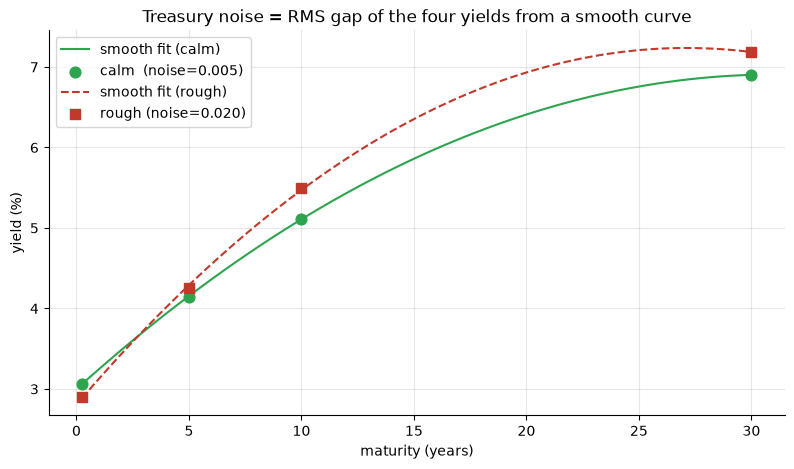

In [2]:
m = data.MATURITIES
P = st._perp_matrix()
smooth = 3.0 + 0.25*m - 0.004*m**2
rng = np.random.default_rng(0)
calm  = smooth + 0.02*rng.standard_normal(4)
rough = smooth + 0.30*rng.standard_normal(4)
grid = np.linspace(0.25, 30, 100)
def fit(y):
    A = np.column_stack([np.ones_like(m), m, m**2]); b,_,_,_ = np.linalg.lstsq(A,y,rcond=None)
    return b[0]+b[1]*grid+b[2]*grid**2
fig, ax = plt.subplots()
ax.plot(grid, fit(calm), color=GREEN, lw=1.5, label='smooth fit (calm)')
ax.scatter(m, calm, color=GREEN, s=60, zorder=5, label=f'calm  (noise={np.sqrt(np.mean((P@calm)**2)):.3f})')
ax.plot(grid, fit(rough), color=RED, lw=1.5, ls='--', label='smooth fit (rough)')
ax.scatter(m, rough, color=RED, s=60, marker='s', zorder=5, label=f'rough (noise={np.sqrt(np.mean((P@rough)**2)):.3f})')
ax.set_xlabel('maturity (years)'); ax.set_ylabel('yield (%)')
ax.set_title('Treasury noise = RMS gap of the four yields from a smooth curve')
ax.legend(); plt.show()

## 2. Is the detector honest? A live synthetic control

Before trusting any real-tape number we plant the effect in a seeded toy world (`edge>0`: high noise really does drag next month's return down) and check the detector recovers it — and that it stays **silent** on the null (`edge=0`: the curve roughens but that roughness means nothing). No network.

In [3]:
null    = st.synthetic_detect(data.synthetic_daily(edge=0.0,  seed=863), target='ret_spy', horizon=21)
planted = st.synthetic_detect(data.synthetic_daily(edge=0.03, seed=863), target='ret_spy', horizon=21)
print('null world   : noise->SPY slope %+.3f%%/1σ  NW t = %+.2f   (should be ~0)' % (null['slope_pct'], null['t_nw']))
print('planted world: noise->SPY slope %+.3f%%/1σ  NW t = %+.2f   (should light up, negative)' % (planted['slope_pct'], planted['t_nw']))

null world   : noise->SPY slope +0.229%/1σ  NW t = +0.88   (should be ~0)
planted world: noise->SPY slope -1.598%/1σ  NW t = -5.76   (should light up, negative)


## 3. The honest verdict

On the real tape (2007-04-12 → 2026-06-30) the noise measure points **exactly the way Hu-Pan-Wang say** — a rougher curve today, weaker stocks tomorrow — and at the one-week horizon it clears the bar (*t* = **-2.2**, -2.39σ into a placebo's left tail). But the edge is a **crisis-era phenomenon**: strong in 2007–2015 (*t* = -2.42), gone after 2016 (*t* = -1.14), and the credit-spread leg only fires in the 2008 meltdown. A noise-timer **loses** to buy-and-hold. So: **Signal Weak** (right sign, real in stress, decays out of sample), **Tradability Mirage**.